In [ ]:
import pandas as pd
import kagglehub
import os
import altair as alt
from vega_datasets import data
import seaborn as sns
import matplotlib.pyplot as plt
import requests

In [ ]:
# Parks visit df
csv_url = "https://raw.githubusercontent.com/melaniewalsh/responsible-datasets-in-context/main/datasets/national-parks/US-National-Parks_Use_1979-2023_By-Month.csv"
parks_visit_df = pd.read_csv(csv_url)
# Biodversity df
path_biodiversity = kagglehub.dataset_download("aliamini587/biodiversity-in-national-parks")
files_biodiversity = os.listdir(path_biodiversity)
csv_file_biodiversity = [f for f in files_biodiversity if f.endswith(".csv")][0]
biodiversity_df = pd.read_csv(os.path.join(path_biodiversity, csv_file_biodiversity))
# Species df
path_species = kagglehub.dataset_download("nationalparkservice/park-biodiversity")
files_species = os.listdir(path_species)
csv_file_species = [f for f in files_species if f.endswith(".csv")][1]
species_df = pd.read_csv(os.path.join(path_species, csv_file_species))

In [ ]:
species_df

,Park Code,Park Name,State,Acres,Latitude,Longitude
0,ACAD,Acadia National Park,ME,47390,44.35,-68.21
1,ARCH,Arches National Park,UT,76519,38.68,-109.57
2,BADL,Badlands National Park,SD,242756,43.75,-102.50
3,BIBE,Big Bend National Park,TX,801163,29.25,-103.25
4,BISC,Biscayne National Park,FL,172924,25.65,-80.08
5,BLCA,Black Canyon of the Gunnison National Park,CO,32950,38.57,-107.72
6,BRCA,Bryce Canyon National Park,UT,35835,37.57,-112.18
7,CANY,Canyonlands National Park,UT,337598,38.20,-109.93
8,CARE,Capitol Reef National Park,UT,241904,38.20,-111.17
9,CAVE,Carlsbad Caverns National Park,NM,46766,32.17,-104.44


In [ ]:
pip install meteostat tqdm

In [ ]:
st.map(species_df, latitude="Latitude", longitude="Longitude", size="Acres")

,Park Code,Park Name,State,Acres,Latitude,Longitude
0,ACAD,Acadia National Park,ME,47390,44.35,-68.21
1,ARCH,Arches National Park,UT,76519,38.68,-109.57
2,BADL,Badlands National Park,SD,242756,43.75,-102.50
3,BIBE,Big Bend National Park,TX,801163,29.25,-103.25
4,BISC,Biscayne National Park,FL,172924,25.65,-80.08
5,BLCA,Black Canyon of the Gunnison National Park,CO,32950,38.57,-107.72
6,BRCA,Bryce Canyon National Park,UT,35835,37.57,-112.18
7,CANY,Canyonlands National Park,UT,337598,38.20,-109.93
8,CARE,Capitol Reef National Park,UT,241904,38.20,-111.17
9,CAVE,Carlsbad Caverns National Park,NM,46766,32.17,-104.44


In [ ]:
parks_visit_df.head()

,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,4,219351,37657,1037,459,0
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,5,339416,50616,3193,1148,0


In [ ]:
biodiversity_df.head()

,Park Code,Park Name,State,Acres,Latitude,Longitude
0,ACAD,Acadia National Park,ME,47390,44.35,-68.21
1,ARCH,Arches National Park,UT,76519,38.68,-109.57
2,BADL,Badlands National Park,SD,242756,43.75,-102.50
3,BIBE,Big Bend National Park,TX,801163,29.25,-103.25
4,BISC,Biscayne National Park,FL,172924,25.65,-80.08


In [ ]:
species_df.head()

,Species ID,Park Name,Category,Order,Family,Scientific Name,Common Names,Record Status,Occurrence,Nativeness,Abundance,Seasonality,Conservation Status,Unnamed: 13
0,ACAD-1000,Acadia National Park,Mammal,Artiodactyla,Cervidae,Alces alces,Moose,Approved,Present,Native,Rare,Resident,NaN,NaN
1,ACAD-1001,Acadia National Park,Mammal,Artiodactyla,Cervidae,Odocoileus virginianus,"Northern White-Tailed Deer, Virginia Deer, Whi...",Approved,Present,Native,Abundant,NaN,NaN,NaN
2,ACAD-1002,Acadia National Park,Mammal,Carnivora,Canidae,Canis latrans,"Coyote, Eastern Coyote",Approved,Present,Not Native,Common,NaN,Species of Concern,NaN
3,ACAD-1003,Acadia National Park,Mammal,Carnivora,Canidae,Canis lupus,"Eastern Timber Wolf, Gray Wolf, Timber Wolf",Approved,Not Confirmed,Native,NaN,NaN,Endangered,NaN
4,ACAD-1004,Acadia National Park,Mammal,Carnivora,Canidae,Vulpes vulpes,"Black Fox, Cross Fox, Eastern Red Fox, Fox, Re...",Approved,Present,Unknown,Common,Breeder,NaN,NaN


In [ ]:
biodiversity_parks_df = pd.merge(parks_visit_df, biodiversity_df, how='left', left_on='UnitCode', right_on='Park Code')
biodiversity_parks_df = biodiversity_parks_df.drop('ParkName', axis=1)

In [ ]:
species_df.columns

Index(['Species ID', 'Park Name', 'Category', 'Order', 'Family',
       'Scientific Name', 'Common Names', 'Record Status', 'Occurrence',
       'Nativeness', 'Abundance', 'Seasonality', 'Conservation Status',
       'Unnamed: 13'],
      dtype='object')

In [ ]:
biodiversity_parks_df.columns

Index(['UnitCode', 'ParkType', 'Region', 'State_x', 'Year', 'Month',
       'RecreationVisits', 'NonRecreationVisits', 'TentCampers', 'RVCampers',
       'Backcountry', 'Park Code', 'Park Name', 'State_y', 'Acres', 'Latitude',
       'Longitude'],
      dtype='object')

In [ ]:
nps_code_map = biodiversity_parks_df[['Park Name', 'UnitCode']].drop_duplicates()

In [ ]:
nps_code_map.columns

Index(['Park Name', 'UnitCode'], dtype='object')

In [ ]:
coded_species_df = pd.merge(nps_code_map, species_df, how='left', on='Park Name')

### 1. Missing values check

In [ ]:
biodiversity_parks_df.isna().sum()

,0
UnitCode,0
ParkType,0
Region,0
State_x,0
Year,0
Month,0
RecreationVisits,0
NonRecreationVisits,0
TentCampers,0
RVCampers,0


### 2. Count of parks per region

In [ ]:
biodiversity_parks_df.groupby('Region').size().reset_index(name='count')

,Region,count
0,Alaska,4128
1,Intermountain,10260
2,Midwest,4860
3,Northeast,1560
4,Pacific West,8879
5,Southeast,3708


In [ ]:
alt.Chart(biodiversity_parks_df.groupby('Region').size().reset_index(name='count')).mark_bar().encode(
    x='Region:N',  # Categorical x-axis
    y='count:Q',  # Quantitative y-axis
    color='Region:N'
).properties(
    title="Parks in region count"
)

alt.Chart(...)

### 3. Total number of visits per park on the map from 1979 to 2023

In [ ]:
biodiversity_parks_df['Total'] = biodiversity_parks_df['RecreationVisits'] + biodiversity_parks_df['NonRecreationVisits'] + biodiversity_parks_df['TentCampers'] + biodiversity_parks_df['RVCampers'] + biodiversity_parks_df['Backcountry']

In [ ]:
df_park_visitors = biodiversity_parks_df.groupby(['Park Name', 'Latitude', 'Longitude'], as_index=False)['Total'].sum()

In [ ]:
us_map = alt.topo_feature(data.us_10m.url, feature='states')

In [ ]:
background = alt.Chart(us_map).mark_geoshape(
    fill='lightgray', stroke='white'
).project(
    type='albersUsa'
).properties(
    width=800, height=500
)

In [ ]:
points = alt.Chart(df_park_visitors).mark_circle().encode(
    longitude='Longitude:Q',
    latitude='Latitude:Q',
    size=alt.Size('Total:Q', scale=alt.Scale(range=[10, 1000]), title="Total Visits"),
    color=alt.Color('Total:Q', scale=alt.Scale(scheme='reds'), title="Total Visits"),
    tooltip=['Park Name:N', 'Total:Q']
)

In [ ]:
map_chart = background + points

In [ ]:
map_chart

alt.LayerChart(...)

In [ ]:
biodiversity_parks_df.columns

Index(['UnitCode', 'ParkType', 'Region', 'State_x', 'Year', 'Month',
       'RecreationVisits', 'NonRecreationVisits', 'TentCampers', 'RVCampers',
       'Backcountry', 'Park Code', 'Park Name', 'State_y', 'Acres', 'Latitude',
       'Longitude', 'Total'],
      dtype='object')

### 4. Visits per month

In [ ]:
df_grouped = biodiversity_parks_df.groupby('Month')['Total'].sum().reset_index()

<Axes: xlabel='Month', ylabel='Total'>

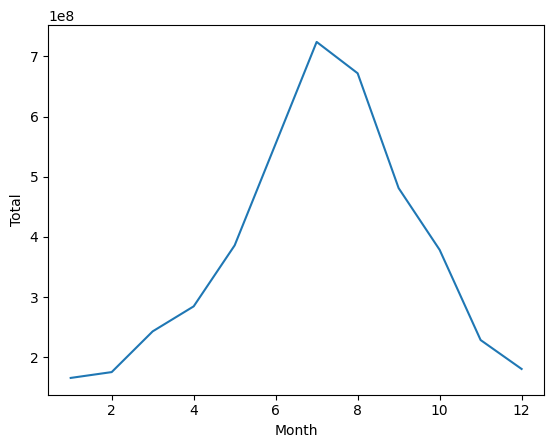

In [ ]:
sns.lineplot(data=df_grouped, x='Month', y='Total')

### 5. Correlations between visits, campers and park size

In [ ]:
biodiversity_parks_df.columns

Index(['UnitCode', 'ParkType', 'Region', 'State_x', 'Year', 'Month',
       'RecreationVisits', 'NonRecreationVisits', 'TentCampers', 'RVCampers',
       'Backcountry', 'Park Code', 'Park Name', 'State_y', 'Acres', 'Latitude',
       'Longitude', 'Total'],
      dtype='object')

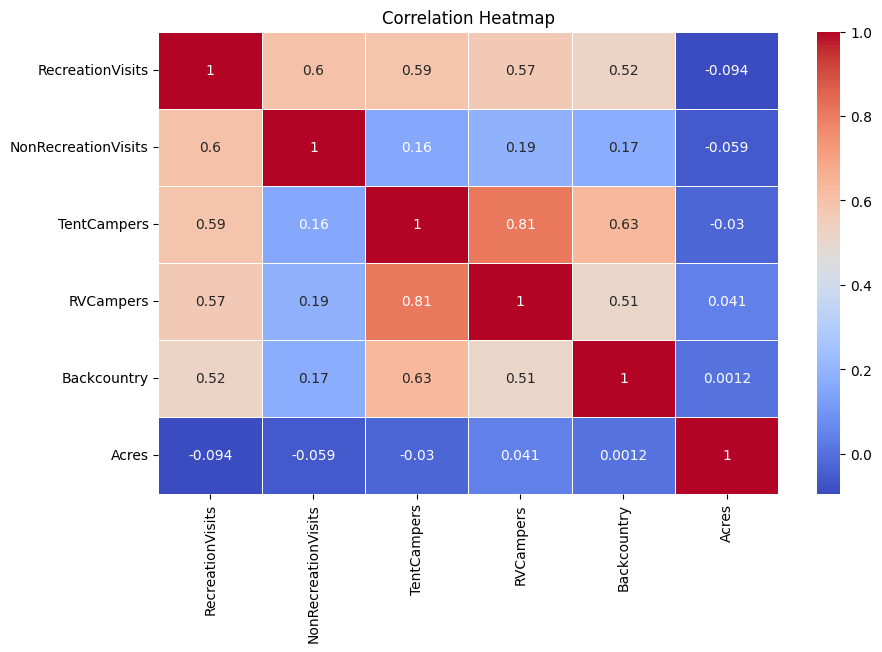

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(biodiversity_parks_df[['RecreationVisits', 'NonRecreationVisits', 'TentCampers', 'RVCampers',
       'Backcountry', 'Acres']].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
biodiversity_parks_df.columns

Index(['UnitCode', 'ParkType', 'Region', 'State_x', 'Year', 'Month',
       'RecreationVisits', 'NonRecreationVisits', 'TentCampers', 'RVCampers',
       'Backcountry', 'Park Code', 'Park Name', 'State_y', 'Acres', 'Latitude',
       'Longitude', 'Total'],
      dtype='object')

In [ ]:
df_grouped = biodiversity_parks_df.groupby(['Region', 'Month'], as_index=False)['Total'].sum()

### 6. Total visitors per month per region of national park based on geography

In [ ]:
alt.Chart(df_grouped).mark_bar().encode(
    x=alt.X('Month:O', title="Month"),
    y=alt.Y('Total:Q', title="Total Visitors"),
    color='Region:N',
    column='Region:N',
    tooltip=['Region', 'Month', 'Total']
).properties(
    title="Total Visitors per Region per Month"
)

alt.Chart(...)

### 7. Visits by state

<ipython-input-30-382ff192f454>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='State_x', y='Total', palette="viridis")


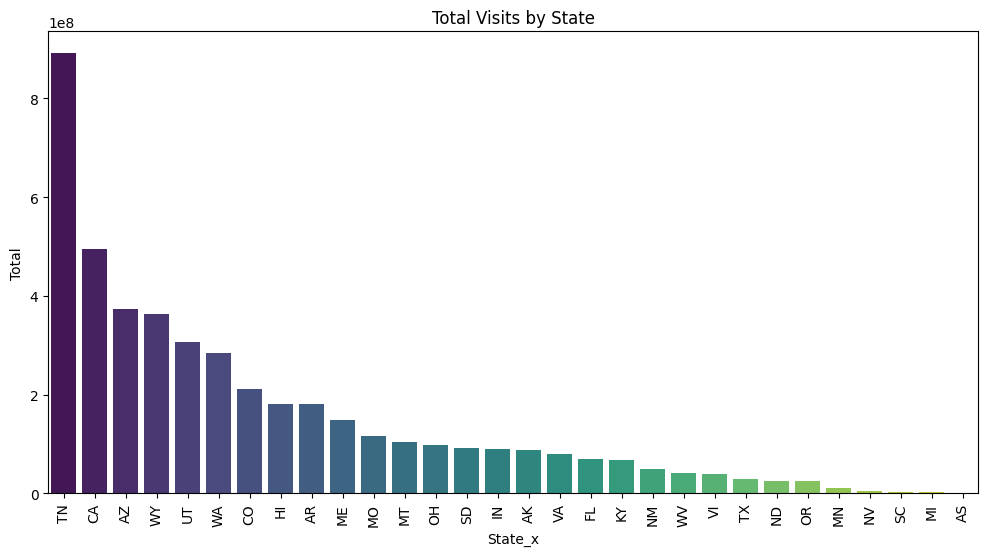

In [ ]:
df_grouped = biodiversity_parks_df.groupby('State_x')['Total'].sum().reset_index()
df_grouped = df_grouped.sort_values('Total', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_grouped, x='State_x', y='Total', palette="viridis")
plt.xticks(rotation=90)
plt.title('Total Visits by State')
plt.show()

### 8. Diversity of national parks per region

In [ ]:
species_filtered_df = coded_species_df[['Species ID', 'Park Name', 'UnitCode', 'Category', 'Order', 'Family', 'Scientific Name', 'Record Status']]

In [ ]:
species_filtered_df.head()

,Species ID,Park Name,UnitCode,Category,Order,Family,Scientific Name,Record Status
0,ACAD-1000,Acadia National Park,ACAD,Mammal,Artiodactyla,Cervidae,Alces alces,Approved
1,ACAD-1001,Acadia National Park,ACAD,Mammal,Artiodactyla,Cervidae,Odocoileus virginianus,Approved
2,ACAD-1002,Acadia National Park,ACAD,Mammal,Carnivora,Canidae,Canis latrans,Approved
3,ACAD-1003,Acadia National Park,ACAD,Mammal,Carnivora,Canidae,Canis lupus,Approved
4,ACAD-1004,Acadia National Park,ACAD,Mammal,Carnivora,Canidae,Vulpes vulpes,Approved


In [ ]:
species_region_df = pd.merge(species_filtered_df, biodiversity_parks_df[['UnitCode', 'Region']].drop_duplicates(), on='UnitCode', how='left')

In [ ]:
species_count = species_region_df.groupby(['Region', 'Category'])['Species ID'].nunique().reset_index()
species_count.rename(columns={'Species ID': 'Number of Species'}, inplace=True)

In [ ]:
species_count

,Region,Category,Number of Species
0,Alaska,Algae,64
1,Alaska,Amphibian,13
2,Alaska,Bird,1557
3,Alaska,Crab/Lobster/Shrimp,101
4,Alaska,Fish,650
...,...,...,...
78,Southeast,Nonvascular Plant,536
79,Southeast,Reptile,249
80,Southeast,Slug/Snail,113
81,Southeast,Spider/Scorpion,127


In [ ]:
alt.Chart(species_count).mark_bar().encode(
    x=alt.X('Region:N', title="Park Region"),
    y=alt.Y('Number of Species:Q', title="Number of Species"),
    color='Category:N',
    tooltip=['Region', 'Category', 'Number of Species']
).properties(
    title="Diversity of Species per Park per Category",
    width=600
)

alt.Chart(...)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Integrate with Weather Data

In [ ]:
# First join with biodiversity dataframe to get latitude and longitude data
import pandas as pd
from geopy.distance import geodesic
from itertools import product

# Parks visit df
csv_url = "https://raw.githubusercontent.com/melaniewalsh/responsible-datasets-in-context/main/datasets/national-parks/US-National-Parks_Use_1979-2023_By-Month.csv"
parks_df = pd.read_csv(csv_url)

# Biodversity df
path_biodiversity = kagglehub.dataset_download("aliamini587/biodiversity-in-national-parks")
files_biodiversity = os.listdir(path_biodiversity)
csv_file_biodiversity = [f for f in files_biodiversity if f.endswith(".csv")][0]
biodiversity_df = pd.read_csv(os.path.join(path_biodiversity, csv_file_biodiversity))

biodiversity_parks_df = pd.merge(parks_df, biodiversity_df, how='left', left_on='UnitCode', right_on='Park Code')
biodiversity_parks_df = biodiversity_parks_df.drop('ParkName', axis=1)

biodiversity_parks_df.head(10)

,UnitCode,ParkType,Region,State_x,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Park Code,Park Name,State_y,Acres,Latitude,Longitude
0,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
1,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
2,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
3,ACAD,National Park,Northeast,ME,1979,4,219351,37657,1037,459,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
4,ACAD,National Park,Northeast,ME,1979,5,339416,50616,3193,1148,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
5,ACAD,National Park,Northeast,ME,1979,6,543205,70776,23821,9819,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
6,ACAD,National Park,Northeast,ME,1979,7,383341,41071,42182,23243,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
7,ACAD,National Park,Northeast,ME,1979,8,466928,50028,45347,23665,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
8,ACAD,National Park,Northeast,ME,1979,9,320138,34300,22762,15276,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21
9,ACAD,National Park,Northeast,ME,1979,10,300976,32246,676,422,0,ACAD,Acadia National Park,ME,47390.0,44.35,-68.21


In [ ]:
unique_unitcodes = biodiversity_parks_df['UnitCode'].unique()
print(unique_unitcodes)

['ACAD' 'ARCH' 'BADL' 'BIBE' 'BISC' 'BLCA' 'BRCA' 'CANY' 'CARE' 'CAVE'
 'CHIS' 'CONG' 'CRLA' 'CUVA' 'DEVA' 'DENA' 'DRTO' 'EVER' 'GAAR' 'JEFF'
 'GLBA' 'GLAC' 'GRCA' 'GRTE' 'GRBA' 'GRSA' 'GRSM' 'GUMO' 'HALE' 'HAVO'
 'HOSP' 'INDU' 'ISRO' 'JOTR' 'KATM' 'KEFJ' 'KICA' 'KOVA' 'LACL' 'LAVO'
 'MACA' 'MEVE' 'MORA' 'NPSA' 'NERI' 'NOCA' 'OLYM' 'PEFO' 'PINN' 'REDW'
 'ROMO' 'SAGU' 'SEQU' 'SHEN' 'THRO' 'VIIS' 'VOYA' 'WHSA' 'WICA' 'WRST'
 'YELL' 'YOSE' 'ZION']


In [ ]:
pip install meteostat pandas tqdm

In [ ]:
# Integrate with weather data using the meteostat library,
# which provides APIs for historical weather data access

import pandas as pd
from datetime import datetime
from meteostat import Point, Monthly, Stations
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import lru_cache

# Find the nearest station for each national park based on coordinates
# Cache station lookups for faster retrieval
@lru_cache(maxsize=1000)
def get_best_station_cached(lat, lon, year):
    stations = Stations().nearby(lat, lon).fetch()
    valid_stations = stations[
        (stations['daily_start'] <= f'{year}-01-01') &
        (stations['daily_end'] >= f'{year}-12-31')
    ]
    return valid_stations.index[0] if not valid_stations.empty else None

# Get weather data for each combination of year and month for each station
@lru_cache(maxsize=10000)
def get_cached_weather(station_id, year, month):
    try:
        weather = Monthly(station_id, datetime(year, month, 1), datetime(year, month, 28)).fetch()
        return weather.iloc[0] if not weather.empty else None
    except:
        return None

# Process each row of the parks df
def process_row(row):
    lat, lon, year, month = row['Latitude'], row['Longitude'], row['Year'], row['Month']

    # Get station ID for the park
    station_id = get_best_station_cached(round(lat,3), round(lon,3), year)

    if not station_id:
        return {
            'UnitCode': row['UnitCode'],
            'Year': year,
            'Month': month,
            'AvgTemp': None,
            'MinTemp': None,
            'MaxTemp': None,
            'Precipitation': None,
            'Snowfall': None,
            'WindSpeed': None,
            'Pressure': None,
            'Sunshine': None
        }

    # Get weather
    weather = get_cached_weather(station_id, year, month)

    if weather is None:
        return {
            'UnitCode': row['UnitCode'],
            'Year': year,
            'Month': month,
            'AvgTemp': None,
            'MinTemp': None,
            'MaxTemp': None,
            'Precipitation': None,
            'Snowfall': None,
            'WindSpeed': None,
            'Pressure': None,
            'Sunshine': None
        }

    return {
        'UnitCode': row['UnitCode'],
        'Year': year,
        'Month': month,
        'AvgTemp': weather.get('tavg'),
        'MinTemp': weather.get('tmin'),
        'MaxTemp': weather.get('tmax'),
        'Precipitation': weather.get('prcp', 0),
        'Snowfall': weather.get('snow', 0),
        'WindSpeed': weather.get('wspd'),
        'Pressure': weather.get('pres'),
        'Sunshine': weather.get('tsun')
    }

# Main routine for intergration
def main():
    # Convert the df to list of dicts
    records = biodiversity_parks_df.to_dict('records')

    weather_records = []
    # Use a ThreadPoolExecutor for parallel processing since this is a time consuming process
    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = [executor.submit(process_row, row) for row in records]

        for future in tqdm(as_completed(futures), total=len(futures)):
            try:
                weather_records.append(future.result())
            except Exception as e:
                print(f"Error processing row: {str(e)}")

    # Create DataFrame and merge
    weather_df = pd.DataFrame(weather_records)
    final_df = pd.merge(
        biodiversity_parks_df,
        weather_df,
        on=['UnitCode', 'Year', 'Month'],
        how='left'
    )

    return final_df

# Run the optimized code with caching
final_df = main()

  0%|          | 9/33395 [00:02<1:37:35,  5.70it/s]

Error processing row: Ran out of input
Error processing row: Ran out of input
Error processing row: invalid load key, '\x00'.
Error processing row: invalid load key, '\x00'.
Error processing row: invalid load key, '\x00'.
Error processing row: invalid load key, '\x00'.


100%|██████████| 33395/33395 [21:30<00:00, 25.88it/s]


In [ ]:
final_df.to_csv('final_weather_data.csv', index=False)